In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
file = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\dataset\train_set_respiratory_irritation_features_rdkitcdk.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf.drop_duplicates(subset=['SMILES'])
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[21:49:59] WARNING: not removing hydrogen atom without neighbors
[21:49:59] WARNING: not removing hydrogen atom without neighbors
[21:49:59] WARNING: not removing hydrogen atom without neighbors
[21:49:59] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:00] WARNING: not removing hydrogen atom without neighbors
[21:50:01] WARNING: not removing hydrogen atom without neighbors


(2933, 67)
(2933, 67)


[21:50:01] WARNING: not removing hydrogen atom without neighbors


Index(['name', 'Outcome', 'ID', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP', 'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3', 'Mol'],
    

In [3]:
moldf

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...,0,1832,1832,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.175334414529006, 1.4122349538592949, 1.0856...",CCN1C(=CC(C)=c2sc(=C3SC(=S)N(CC(=O)O)C3=O)n(CC...,549.0156693279998,1.6916999999999993,...,3.0,3.0,0.4666666666666667,6.0,1.0,231.08,6.247927513443585,-0.3169999999999995,0.2272727272727272,<rdkit.Chem.rdchem.Mol object at 0x0000025439D...
1,propyl nitrate,1,773,773,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2860540529351707, -0.32496784885868896, -0...",CCCO[N+](=O)[O-],105.042593084,0.6047,...,3.0,6.0,0.4,3.0,0.0,52.370000000000005,3.584962500721156,1.234,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000025439D...
2,dipotassium;5-[[4-anilino-6-[bis(2-hydroxyethy...,0,2998,2998,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.1319183827956505, 2.989609123825066, 3.3086...",O=S(=O)([O-])c1cc(Nc2nc(Nc3ccccc3)nc(N(CCO)CCO...,992.1862409040001,-3.400399999999994,...,2.0,7.0,0.999000000999,22.0,4.0,344.02,7.10852445677817,1.9740000000000013,0.2,<rdkit.Chem.rdchem.Mol object at 0x0000025439D...
3,methanol,1,42,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7527304411259781, -0.7237925679693525, -0....",CO,32.026214748,-0.3915,...,0.0,2.0,0.0,0.0,0.0,20.23,1.0,-0.499,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000025439D...
4,nickel(2+);diperchlorate,1,1760,1760,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.673030151195501, -0.6346669440981806, 0.848...",[Ni+2].[O-][Cl+3]([O-])([O-])[O-].[O-][Cl+3]([...,255.83236522000004,-9.5145,...,0.0,3.0,0.999000000999,0.0,0.0,184.48,4.0,-2.712,0.0,<rdkit.Chem.rdchem.Mol object at 0x0000025439D...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,2-methylpropan-1-olate;titanium(4+),0,3280,3280,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.14173263623973606, -0.28015608266647957, -0...",CC(C)C[O-].CC(C)C[O-].CC(C)C[O-].CC(C)C[O-].[T...,340.209305932,0.008300000000002639,...,3.0,4.0,0.999000000999,4.0,0.0,92.24,5.0,2.3160000000000003,1.0,<rdkit.Chem.rdchem.Mol object at 0x00000254411...
2929,2-(1-propoxyethoxy)ethylbenzene,0,3445,3445,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.23160847431290987, -0.11435254775530485, -...",CCCOC(C)OCCc1ccccc1,208.14632988,3.0183000000000018,...,3.0,8.0,0.4545454545454545,7.0,0.0,18.46,4.906890595608519,3.076000000000001,0.5384615384615384,<rdkit.Chem.rdchem.Mol object at 0x00000254411...
2930,N-cyclohexylcyclohexanamine;nitrous acid,0,2150,2150,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.23160847431290987, -0.14123960747063047, -...",C1CCC(NC2CCCCC2)CC1.O=NO,228.183778008,3.3834000000000017,...,0.0,3.0,0.999000000999,2.0,0.0,61.69,5.0,3.737,1.0,<rdkit.Chem.rdchem.Mol object at 0x00000254411...
2931,strontium;oxoarsinite;tetrahydrate,1,1347,1347,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0.05644203159416418, -0.7246224154914306, -0....",O.O.O.O.O=[As][O-].O=[As][O-].[Sr+2],373.770722316,-7.056799999999996,...,0.0,3.0,0.999000000999,0.0,0.0,80.25999999999999,3.0,-2.5020000000000007,0.0,<rdkit.Chem.rdchem.Mol object at 0x00000254411...


In [4]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
#moldf['RowID'] = moldf.index
moldf.head(100)

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...,0,1832,1832,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.175334414529006, 1.4122349538592949, 1.0856...",CCN1C(=CC(C)=c2sc(=C3SC(=S)N(CC(=O)O)C3=O)n(CC...,549.0156693279998,1.6916999999999993,...,3.0,3.0,0.4666666666666667,6.0,1.0,231.08,6.247927513443585,-0.3169999999999995,0.2272727272727272,<rdkit.Chem.rdchem.Mol object at 0x0000025439D...
1207,4-[(3-chlorophenyl)-imidazol-1-ylmethyl]benzen...,0,2528,2528,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.11254135599076372, 0.4821418511143267, 0.27...",Cl.Cl.Nc1ccc(C(c2cccc(Cl)c2)n2ccnc2)cc1N,370.05187958400006,4.182200000000003,...,0.0,0.0,0.999000000999,3.0,0.0,69.86,5.523561956057013,3.563,0.0625,<rdkit.Chem.rdchem.Mol object at 0x000002543C5...
1206,undecylbenzene,0,2130,2130,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45716872860513347, -0.2711937294280377, -0...",CCCCCCCCCCCc1ccccc1,232.219100896,5.759900000000005,...,11.0,11.0,0.5,10.0,1.0,0.0,5.08746284125034,8.043999999999999,0.6470588235294118,<rdkit.Chem.rdchem.Mol object at 0x000002543C5...
1205,zinc;hexadecanoate;octadecanoate,0,1834,1834,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0.40618258954786024, 0.31135923107068436, -0....",CCCCCCCCCCCCCCCC(=O)[O-].CCCCCCCCCCCCCCCCCC(=O...,602.4252527919999,9.212900000000001,...,18.0,19.0,0.999000000999,30.0,3.0,80.25999999999999,6.169925001442312,15.31600000000001,0.9411764705882352,<rdkit.Chem.rdchem.Mol object at 0x000002543C5...
1203,"2-chlorobenzene-1,4-diamine",0,2046,2046,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4898168709888525, -0.29758288063011656, -0...",Nc1ccc(N)c(Cl)c1,142.029775904,1.5044000000000002,...,0.0,0.0,0.4,0.0,0.0,52.04,4.169925001442312,1.01,0.0,<rdkit.Chem.rdchem.Mol object at 0x000002543C5...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2354,"propan-2-yl 2-(2,4-dichlorophenoxy)acetate",0,2006,2006,"[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.016898926165863516, 0.12862680670911944, -...",CC(C)OC(=O)COc1ccc(Cl)cc1Cl,262.016349604,3.323800000000002,...,3.0,6.0,0.5,5.0,0.0,35.53,5.0,3.767,0.3636363636363636,<rdkit.Chem.rdchem.Mol object at 0x000002543FD...
1149,tetraethylplumbane,0,1882,1882,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7760537657609485, -0.7084867309452603, -0....",C[CH2][Pb]([CH2]C)([CH2]C)[CH2]C,324.13315274,3.514800000000003,...,2.0,5.0,0.5,4.0,0.0,0.0,4.0,3.544,1.0,<rdkit.Chem.rdchem.Mol object at 0x000002543C5...
2355,"sodium;1,4-bis(2-ethylhexoxy)-1,4-dioxobutane-...",0,3498,3498,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5945815758915566, 0.24264785624263005, 0.45...",CCCCC(CC)COC(=O)CC(C(=O)OCC(CC)CCCC)S(=O)(=O)[...,444.215768804,0.8135000000000032,...,7.0,18.0,0.999000000999,18.0,2.0,118.18,5.754887502163469,5.040000000000001,0.9,<rdkit.Chem.rdchem.Mol object at 0x000002543FD...
1147,4-ethylmorpholine;4-(4-methylphenyl)-4-oxobuta...,0,3317,3317,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0673074728181708, 1.1000463160535696, 0.565...",CCN1CCOCC1.Cc1ccc(C(=O)CCC(=O)O)cc1.Cc1ccc(C(=...,499.2570025239999,4.423540000000003,...,4.0,6.0,0.999000000999,9.0,0.0,121.21,6.169925001442312,3.498,0.4285714285714285,<rdkit.Chem.rdchem.Mol object at 0x000002543C5...


In [5]:
x_data = moldf.drop(columns=['name', 'Outcome', 'ID', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight','logP','Mol'])
print(x_data)

               LabuteASA               TPSA                 AMW  \
0     216.58147968996823             120.15   549.6770000000004   
1207   151.8385476605837              69.86  371.69900000000007   
1206   107.4457663778597                0.0             232.411   
1205   256.5830117034913  80.25999999999999   604.2880000000007   
1203  58.414450740404064              52.04  142.58900000000003   
...                  ...                ...                 ...   
1294   27.81733190103448              34.14             150.709   
1293  17.964098032124472                0.0              63.546   
1291   113.7916498206688              27.69             321.549   
1288   33.38393955462742              12.03              73.139   
2932  216.58281921646872              156.3   544.8850000000001   

     NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
0                10              2                 6      2     10   
1207              4              2                 3   

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y_data = le.transform( moldf['Outcome'] )

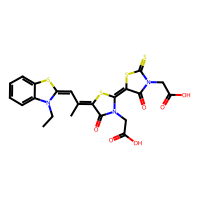

CCN1C(=CC(C)=c2sc(=C3SC(=S)N(CC(=O)O)C3=O)n(CC(=O)O)c2=O)Sc2ccccc21


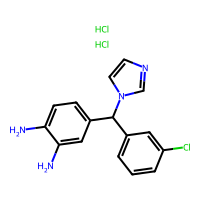

Cl.Cl.Nc1ccc(C(c2cccc(Cl)c2)n2ccnc2)cc1N


In [8]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(df, num_mols):
    for _, row in df.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image
display_molecules_in_column(moldf, 2)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [1456 1477]
Total number of cpds             :  2933


{'0': 0, '1': 1}

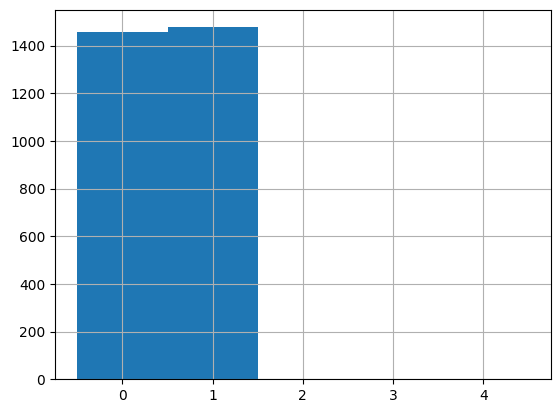

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( moldf['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = moldf['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph 
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [10]:
#initiate x and y
x = x_data
y = y_data

In [11]:
x

,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,216.58147968996823,120.15,549.6770000000004,10,2,6,2,10,1,13,...,2.0,3.0,3.0,0.4666666666666667,6.0,1.0,231.08,6.247927513443585,-0.3169999999999995,0.2272727272727272
1207,151.8385476605837,69.86,371.69900000000007,4,2,3,2,4,0,7,...,2.0,0.0,0.0,0.999000000999,3.0,0.0,69.86,5.523561956057013,3.563,0.0625
1206,107.4457663778597,0.0,232.411,0,0,10,0,0,0,0,...,0.0,11.0,11.0,0.5,10.0,1.0,0.0,5.08746284125034,8.043999999999999,0.6470588235294118
1205,256.5830117034913,80.25999999999999,604.2880000000007,4,0,30,0,4,0,5,...,0.0,18.0,19.0,0.999000000999,30.0,3.0,80.25999999999999,6.169925001442312,15.31600000000001,0.9411764705882352
1203,58.414450740404064,52.04,142.58900000000003,2,2,0,2,2,0,3,...,2.0,0.0,0.0,0.4,0.0,0.0,52.04,4.169925001442312,1.01,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,27.81733190103448,34.14,150.709,2,0,0,0,2,0,3,...,0.0,0.0,3.0,0.5,0.0,0.0,34.14,2.0,-0.798,0.0
1293,17.964098032124472,0.0,63.546,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1291,113.7916498206688,27.69,321.549,4,0,4,0,4,0,8,...,0.0,0.0,5.0,0.5,4.0,1.0,69.59,5.0,5.044,0.25
1288,33.38393955462742,12.03,73.139,1,1,1,1,1,0,1,...,1.0,3.0,4.0,0.3333333333333333,1.0,0.0,12.03,3.0,0.7070000000000001,1.0


In [12]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [15]:
# Random Forest 
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Param grid
paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12, x.shape[1] // 10,
        x.shape[1] // 7, x.shape[1] // 5, x.shape[1] // 3
    ],
#     "n_estimators": [10, 100, 300, 500],
    "n_estimators": [200],
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk RandomForest
model_rf_physicochemical = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1)  

# Fit model
model_rf_physicochemical.fit(x, y)

# Best model
best_model_rf_physicochemical = model_rf_physicochemical.best_estimator_

print("Best parameters found: ", model_rf_physicochemical.best_params_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters found:  {'max_features': 14, 'n_estimators': 200}


In [16]:
#Random Forest 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_rf_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_physicochemical.predict(X_test)
    y_proba = best_model_rf_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[206  86]
 [102 193]]
Confusion Matrix for Fold 2:
[[202  89]
 [ 79 217]]
Confusion Matrix for Fold 3:
[[200  91]
 [ 96 200]]
Confusion Matrix for Fold 4:
[[190 101]
 [108 187]]
Confusion Matrix for Fold 5:
[[207  84]
 [102 193]]
Overall CV Accuracy: 0.6801791954230163
Overall CV AUC: 0.7347351673755526
Overall CV Precision: 0.6868496561298297
Overall CV Recall (Sensitivity): 0.6702313330279432
Overall CV F1 Score: 0.678233942810426
Overall CV Specificity: 0.6902367838817492
Overall CV PPV (Positive Predictive Value): 0.6868496561298297
Overall CV NPV (Negative Predictive Value): 0.6741709719420133
Overall CV CCR (Correct Classification Rate): 0.6802340584548462


In [25]:
# SVM 
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC

# Param grid
paramgrid = {
     "C": [1,2,10],  # Regularization parameter
     "kernel": ['rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient
}


# Cross-validator (5 splits)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk SVM
model_svm_physicochemical = GridSearchCV(
    estimator=SVC(probability=True),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  
)

# Fit model
model_svm_physicochemical.fit(x, y)

# Best model
best_model_svm_physicochemical = model_svm_physicochemical.best_estimator_

print("Best parameters found: ", model_svm_physicochemical.best_params_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:  {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [26]:
#SVM 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_svm_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_physicochemical.predict(X_test)
    y_proba = best_model_svm_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[278  14]
 [225  70]]
Confusion Matrix for Fold 2:
[[263  28]
 [230  66]]
Confusion Matrix for Fold 3:
[[271  20]
 [228  68]]
Confusion Matrix for Fold 4:
[[268  23]
 [238  57]]
Confusion Matrix for Fold 5:
[[273  18]
 [223  72]]
Overall CV Accuracy: 0.5748358925757743
Overall CV AUC: 0.5771491823805548
Overall CV Precision: 0.7641376531270149
Overall CV Recall (Sensitivity): 0.22545579477782868
Overall CV F1 Score: 0.34800946379917364
Overall CV Specificity: 0.9292425740243845
Overall CV PPV (Positive Predictive Value): 0.7641376531270149
Overall CV NPV (Negative Predictive Value): 0.5418572246767701
Overall CV CCR (Correct Classification Rate): 0.5773491844011066


In [23]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

object_cols = x.select_dtypes(include=['object']).columns

for col in object_cols:
    try:
        x[col] = pd.to_numeric(x[col])
    except ValueError:
        x[col] = x[col].astype('category')

paramgrid = {
    "max_depth": [5,10],          
    "n_estimators": [230,260],           
    "learning_rate": [0.01,0.02],   
    "subsample": [0.8],              
    "colsample_bytree": [0.8],  
    "reg_lambda": [2,3]            
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring Cohen's Kappa
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV untuk XGBClassifier
model_xgb_physicochemical = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit model
model_xgb_physicochemical.fit(x, y)

# Best model
best_model_xgb_physicochemical = model_xgb_physicochemical.best_estimator_

print("Best parameters found: ", model_xgb_physicochemical.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 10, 'n_estimators': 260, 'reg_lambda': 2, 'subsample': 0.8}


In [24]:
#XGB Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_xgb_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_physicochemical.predict(X_test)
    y_proba = best_model_xgb_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[204  88]
 [ 95 200]]
Confusion Matrix for Fold 2:
[[196  95]
 [ 78 218]]
Confusion Matrix for Fold 3:
[[207  84]
 [ 99 197]]
Confusion Matrix for Fold 4:
[[189 102]
 [106 189]]
Confusion Matrix for Fold 5:
[[209  82]
 [105 190]]
Overall CV Accuracy: 0.6815420574332378
Overall CV AUC: 0.7393833186169445
Overall CV Precision: 0.6880023261906365
Overall CV Recall (Sensitivity): 0.6729477782867613
Overall CV F1 Score: 0.6800243165311548
Overall CV Specificity: 0.6902414913147861
Overall CV PPV (Positive Predictive Value): 0.6880023261906365
Overall CV NPV (Negative Predictive Value): 0.6760712729046627
Overall CV CCR (Correct Classification Rate): 0.6815946348007738


In [39]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [
        (64,), (128,), (64,32), (128,64,32), (64,32,16)
    ],
    "activation": ["relu"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
    "learning_rate_init": [0.001, 0.005, 0.01],
    "batch_size": [32, 64, 128]
}


cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_physicochemical = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_nn_physicochemical.fit(x, y)
best_model_nn_physicochemical = model_nn_physicochemical.best_estimator_

print("Best Params:", model_nn_physicochemical.best_params_)
print("Best Score :", model_nn_physicochemical.best_score_)


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Params: {'activation': 'relu', 'alpha': 0.001, 'batch_size': 64, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.005, 'solver': 'adam'}
Best Score : 0.3018947246908109


In [40]:
#NN Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Konversi ke Numpy Array dari pandas.df
if isinstance(x, pd.DataFrame):
    X_data = x.values
else:
    X_data = x

if isinstance(y, pd.Series):
    y_data = y.values
else:
    y_data = y

# Cross-validation loop
for train_index, test_index in cv.split(X_data, y_data):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit the model
    best_model_nn_physicochemical.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_nn_physicochemical.predict(X_test)
    y_proba = best_model_nn_physicochemical.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[216  76]
 [145 150]]
Confusion Matrix for Fold 2:
[[208  83]
 [132 164]]
Confusion Matrix for Fold 3:
[[248  43]
 [200  96]]
Confusion Matrix for Fold 4:
[[245  46]
 [147 148]]
Confusion Matrix for Fold 5:
[[222  69]
 [153 142]]
Overall CV Accuracy: 0.6270159485089336
Overall CV AUC: 0.6577842369308192
Overall CV Precision: 0.6908408574876758
Overall CV Recall (Sensitivity): 0.47398076042143833
Overall CV F1 Score: 0.5575656820470823
Overall CV Specificity: 0.782309466647837
Overall CV PPV (Positive Predictive Value): 0.6908408574876758
Overall CV NPV (Negative Predictive Value): 0.5961348169184573
Overall CV CCR (Correct Classification Rate): 0.6281451135346376


In [28]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "num_leaves": [31, 63],
    "min_child_samples": [20, 30]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_physicochemical = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# fit model
model_lgbm_physicochemical.fit(x, y)
best_model_lgbm_physicochemical = model_lgbm_physicochemical.best_estimator_

print("Best Params:", model_lgbm_physicochemical.best_params_)
print("Best Score :", model_lgbm_physicochemical.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 30, 'n_estimators': 150, 'num_leaves': 63}
Best Score : 0.39751435979224753


In [32]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # gunakan iloc untuk baris
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_physicochemical.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_physicochemical.predict(X_test)
    y_proba = best_model_lgbm_physicochemical.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[200  92]
 [100 195]]
Confusion Matrix for Fold 2:
[[202  89]
 [ 79 217]]
Confusion Matrix for Fold 3:
[[202  89]
 [ 94 202]]
Confusion Matrix for Fold 4:
[[190 101]
 [101 194]]
Confusion Matrix for Fold 5:
[[217  74]
 [105 190]]
Overall CV Accuracy: 0.6849573524196033
Overall CV AUC: 0.7354539579516901
Overall CV Precision: 0.6920149998901198
Overall CV Recall (Sensitivity): 0.675650480989464
Overall CV F1 Score: 0.6833382180191347
Overall CV Specificity: 0.6943746175210657
Overall CV PPV (Positive Predictive Value): 0.6920149998901198
Overall CV NPV (Negative Predictive Value): 0.6789588629482171
Overall CV CCR (Correct Classification Rate): 0.685012549255265


In [41]:
# Save model
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\model\physical chemical properties model"

joblib.dump(
    best_model_rf_physicochemical,
    fr"{base_path}\Model_Respiratory_RF_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_physicochemical,
    fr"{base_path}\Model_Respiratory_SVM_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_physicochemical,
    fr"{base_path}\Model_Respiratory_XGB_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_physicochemical,
    fr"{base_path}\Model_Respiratory_NN_rdkit_cdk.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_physicochemical,
    fr"{base_path}\Model_Respiratory_LGBM_rdkit_cdk.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Respiratory Irritation\\model\\physical chemical properties model\\Model_Respiratory_LGBM_rdkit_cdk.pkl']